In [112]:
import pandas as pd

In [114]:
import matplotlib.pyplot as plt

In [116]:
from sklearn.model_selection import train_test_split

In [118]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [120]:
from sklearn.linear_model import LogisticRegression

In [122]:
from sklearn.tree import DecisionTreeClassifier

In [124]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc

In [126]:
df = pd.read_csv('blood_donor_dataset.csv')

In [128]:
df.head(5)

,donor_id,name,email,password,contact_number,city,blood_group,availability,months_since_first_donation,number_of_donation,pints_donated,created_at
0,1b8b4c828a,Norma Fisher,ysullivan@yahoo.com,P5hX6Syg*A,+61 461706749,Hobart,A+,No,65,31,62,2017-03-17
1,a6a3f7fe55,Eugene Bowman,hramos@brown-sellers.com,b6Wq6Cqz@5,+61 450709944,Darwin,AB-,Yes,64,8,16,2016-11-11
2,cee6478144,Sheri Bolton DDS,jasmine85@hotmail.com,$9RB51m#s7,+61 428756361,Melbourne,AB+,Yes,39,6,6,2022-02-25
3,5986bc55f9,Kelly Boyd,pattylawrence@riley-hayes.com,@5Tdg(4kCm,+61 454318320,Darwin,A-,No,55,20,20,2025-04-04
4,93246afe6c,Taylor Guzman,martinezjacob@wilson.com,x!)9Ag@J*7,+61 484158472,Darwin,O-,No,7,35,35,2022-11-30


In [130]:
empty_cells_check=df.isnull().any(). any()

In [132]:
print(f"Are there any empty cells? {empty_cells_check}")

Are there any empty cells? False


In [134]:
duplicates = df.duplicated()

In [136]:
print(duplicates)

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool


In [138]:
if duplicates.any():
    print("There are duplicate rows in the dataframe.")
else:
    print("No duplicates rows found.")

No duplicates rows found.


In [140]:
df['availability'] = df['availability'].str.strip().str.title() 

In [142]:
counts = df['availability'].value_counts()

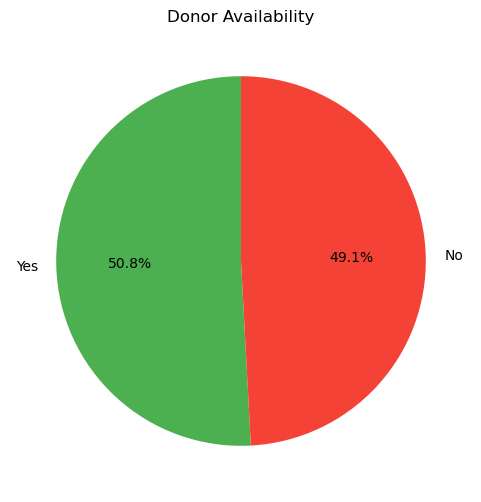

In [144]:
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90, colors=["#4CAF50","#F44336"])
ax.set_title("Donor Availability")
plt.show()

In [146]:
df['blood_group'] = df['blood_group'].str.upper().str.strip()

In [148]:
counts = df['blood_group'].value_counts().sort_values(ascending=False)

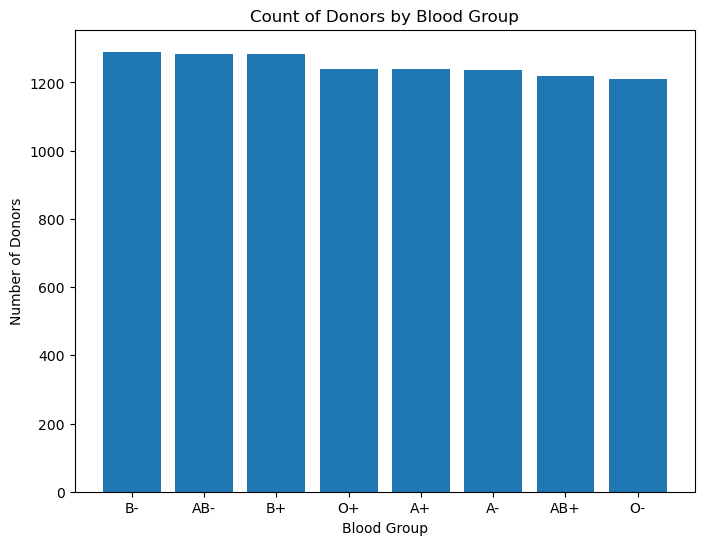

In [150]:
fig, ax = plt.subplots(figsize=(8,6))
ax.bar(counts.index, counts.values, color="#1f77b4")
ax.set_title("Count of Donors by Blood Group")
ax.set_xlabel("Blood Group")
ax.set_ylabel("Number of Donors")
plt.show()

In [152]:
df['created_at'] = pd.to_datetime(df['created_at'])

In [154]:
df['year'] = df['created_at'].dt.year
donations_by_year = df.groupby('year')['number_of_donation'].sum()

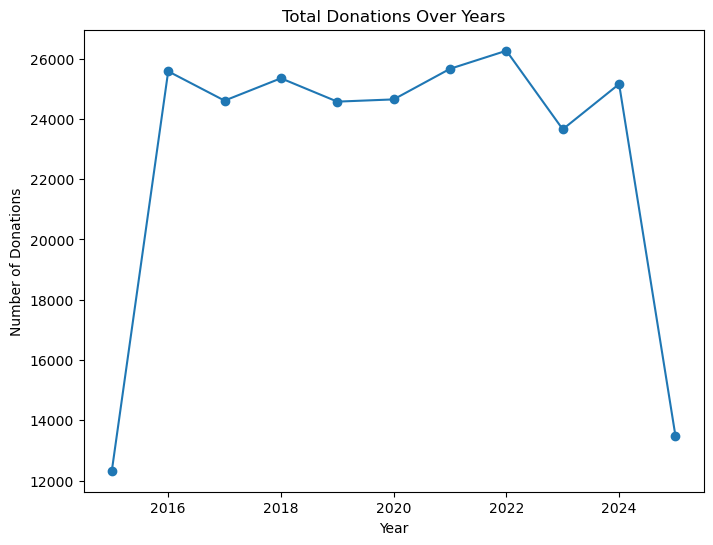

In [156]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(donations_by_year.index, donations_by_year.values, marker='o', color="#1f77b4")
ax.set_title("Total Donations Over Years")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Donations")
plt.show()

In [159]:
X = df[['blood_group']]
y = df['availability']

In [161]:
one_hot_enc = OneHotEncoder(drop='first')
X_encoded = one_hot_enc.fit_transform(X).toarray()

In [163]:
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)

In [165]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)

In [167]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

In [169]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [171]:
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))

Logistic Regression:
Accuracy: 0.5076666666666667
Precision: 0.5069351230425055
Recall: 0.7513262599469496


In [173]:
print("\nDecision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))


Decision Tree:
Accuracy: 0.5076666666666667
Precision: 0.5069351230425055
Recall: 0.7513262599469496


ROC Curve

In [175]:
y_prob_log = log_reg.predict_proba(X_test)[:,1]
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [178]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

In [180]:
roc_auc_log = auc(fpr_log, tpr_log)
roc_auc_dt = auc(fpr_dt, tpr_dt)

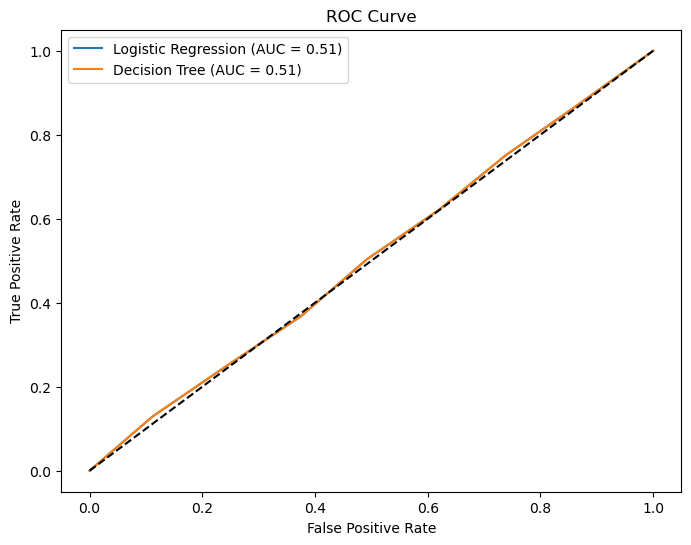

In [185]:
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()